# Validation — prot2exon vs ensembldb

prot2exon and the community-standard tool (ensembldb's
`proteinToGenome`) are run against the **same 5,000-query stratified
set** and their genomic intervals are compared. This notebook loads the
agreement table (`table1.tsv` produced by
`benchmarks/validate_vs_ensembldb.py`) and renders the headline figure.

See the [Validation wiki page](../wiki/Validation.md) for the full
design rationale (why ensembldb, the 9 strata, classifier buckets,
gotchas), and `benchmarks/README.md` for the reproduction recipe.

## Setup

In [1]:
# Force the inline backend — under `jupyter nbconvert --execute` the
# default sometimes lands on Agg, which prints `<Figure …>` instead of
# the actual PNG. The magic call forces module://matplotlib_inline.backend_inline.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass  # Not in IPython (e.g. plain python REPL); ignore.
import matplotlib as mpl
import matplotlib.pyplot as plt

# Paper-ready figure defaults. Tweaks vs matplotlib's stock style:
#   - Larger fonts (10pt body, 11pt axis labels, 12pt title).
#   - Thinner spines + only-left/-bottom by default (less chartjunk).
#   - Subtle horizontal grid; no vertical grid.
#   - tab10 palette but used sparingly — we override per-plot.
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'semibold',
    'axes.titlepad': 10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#e5e7eb',
    'grid.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.frameon': False,
    'legend.fontsize': 10,
    'lines.linewidth': 2.0,
})

# Colorblind-safe palette (Wong 2011, also used in seaborn's 'colorblind').
COLORS = {
    'prot2exon':   '#0072B2',  # blue
    'ensembldb':   '#009E73',  # bluish green
    'transvar':    '#E69F00',  # orange
    'rest':        '#CC79A7',  # reddish-purple
    'good':        '#009E73',
    'bad':         '#D55E00',  # vermilion (works for colorblind)
    'neutral':     '#56B4E9',
    'highlight':   '#F0E442',
}

import pandas as pd
from pathlib import Path

# Validation results land here when the script is run with the recipe
# in benchmarks/README.md.  Override if you ran it somewhere else.
DATA = Path.home() / "Desktop" / "protein2genomic_data"
V86   = DATA / "validation_v86"      # matched-annotation path
V113  = DATA / "validation_v113"     # annotation-drift path

for d in (V86, V113):
    assert (d / "table1.tsv").exists(), f"missing {d}/table1.tsv — run benchmarks/validate_vs_ensembldb.py"
print(f"v86  : {V86}")
print(f"v113 : {V113}")

v86  : /home/goguxor/Desktop/protein2genomic_data/validation_v86
v113 : /home/goguxor/Desktop/protein2genomic_data/validation_v113


## 1. Matched-annotation path (v86)

Both tools were given the same Ensembl 86 GTF / EnsDb. Any disagreement
here would be a **prot2exon mapping bug** — there's no annotation
drift to blame.

In [2]:
t86 = pd.read_csv(V86 / "table1.tsv", sep="\t")
t86

,category,n,exact_match,off_by_one,structural_mismatch,only_prot2exon,only_ensembldb,neither_mapped,exact_pct
0,OVERALL,5000,5000,0,0,0,0,0,100.0
1,cds_incomplete,200,200,0,0,0,0,0,100.0
2,codon_split_boundary,500,500,0,0,0,0,0,100.0
3,many_exon_gene,100,100,0,0,0,0,0,100.0
4,minus_strand_gene,1000,1000,0,0,0,0,0,100.0
5,multi_exon_domain,1000,1000,0,0,0,0,0,100.0
6,plus_strand_gene,1000,1000,0,0,0,0,0,100.0
7,selenoprotein,100,100,0,0,0,0,0,100.0
8,single_exon_domain,1000,1000,0,0,0,0,0,100.0
9,single_exon_gene,100,100,0,0,0,0,0,100.0


In [3]:
# Headline: 100% on every stratum, including the historically hardest
# (codon-split, minus-strand, selenoprotein).
overall = t86.query("category == 'OVERALL'").iloc[0]
print(f"Overall exact-match: {overall['exact_match']:,} / {overall['n']:,}  "
      f"({overall['exact_pct']:.2f}%)")
print(f"Off-by-one         : {overall['off_by_one']}")
print(f"Structural         : {overall['structural_mismatch']}")
print(f"only_prot2exon     : {overall['only_prot2exon']}")
print(f"only_ensembldb     : {overall['only_ensembldb']}")

Overall exact-match: 5,000 / 5,000  (100.00%)
Off-by-one         : 0
Structural         : 0
only_prot2exon     : 0
only_ensembldb     : 0


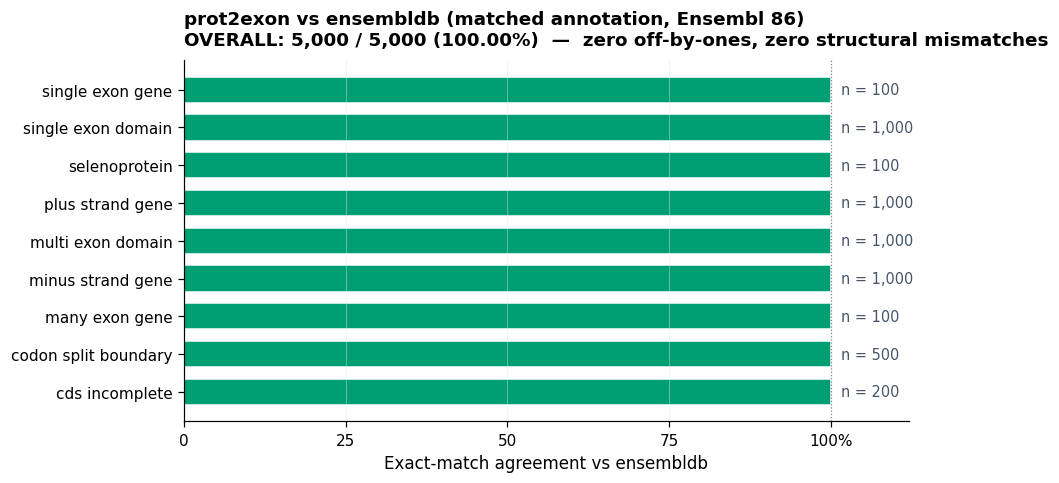

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))

# Pretty-print stratum names: replace underscores with spaces.
strata = (t86.query("category != 'OVERALL'")
            .assign(label=lambda d: d["category"].str.replace("_", " "))
            .sort_values("exact_pct", kind="stable"))

bars = ax.barh(strata["label"], strata["exact_pct"],
               color=COLORS['good'], edgecolor="white", height=0.7)

# Annotate each bar with its n (the stratum size). The label sits to the
# right of the 100% mark so it never overlaps the bar fill.
for bar, (_, row) in zip(bars, strata.iterrows()):
    ax.text(101.5, bar.get_y() + bar.get_height() / 2,
            f"n = {int(row['n']):,}",
            va="center", fontsize=9.5, color="#475569")

ax.set_xlim(0, 112)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(["0", "25", "50", "75", "100%"])
ax.axvline(100, ls=":", color="#0f172a", lw=0.8, alpha=0.5)
ax.set_xlabel("Exact-match agreement vs ensembldb")
ax.set_title(f"prot2exon vs ensembldb (matched annotation, Ensembl 86)\n"
             f"OVERALL: {overall['exact_match']:,} / {overall['n']:,} "
             f"({overall['exact_pct']:.2f}%)  —  zero off-by-ones, zero structural mismatches",
             loc='left')
ax.grid(axis='x', alpha=0.4, lw=0.7)
ax.grid(axis='y', visible=False)

fig.tight_layout()
plt.show()

## 2. Annotation-drift path (v113)

Same comparison logic, but **prot2exon uses GENCODE v49** and
**ensembldb uses the v113 EnsDb via AnnotationHub**. The mapping
logic still agrees 100% on the queries where both tools return data —
the lower headline number is the v113 EnsDb missing CDS linkage for
many ENSPs that *do* exist in its `protein` table (an EnsDb gap, not
a prot2exon bug). See the Validation wiki page §gotcha #5.

In [5]:
t113 = pd.read_csv(V113 / "table1.tsv", sep="\t")
overall113 = t113.query("category == 'OVERALL'").iloc[0]
both_returned = overall113["exact_match"] + overall113["off_by_one"] + overall113["structural_mismatch"]
print(f"Overall: {overall113['exact_match']:,} exact / "
      f"{both_returned:,} both-tools-returned-data / "
      f"{overall113['n']:,} total")
print(f"Exact-match on overlapping set: "
      f"{100*overall113['exact_match']/both_returned:.2f}%")
print()
print(f"  only_prot2exon: {overall113['only_prot2exon']:,} ← EnsDb gap, not a bug")
print(f"  off_by_one    : {overall113['off_by_one']}")
print(f"  structural    : {overall113['structural_mismatch']}")
t113

Overall: 2,264 exact / 2,264 both-tools-returned-data / 5,000 total
Exact-match on overlapping set: 100.00%

  only_prot2exon: 2,736 ← EnsDb gap, not a bug
  off_by_one    : 0
  structural    : 0


,category,n,exact_match,off_by_one,structural_mismatch,only_prot2exon,only_ensembldb,neither_mapped,exact_pct
0,OVERALL,5000,2264,0,0,2736,0,0,45.28
1,cds_incomplete,200,199,0,0,1,0,0,99.50
2,codon_split_boundary,500,189,0,0,311,0,0,37.80
3,many_exon_gene,100,35,0,0,65,0,0,35.00
4,minus_strand_gene,1000,431,0,0,569,0,0,43.10
5,multi_exon_domain,1000,401,0,0,599,0,0,40.10
6,plus_strand_gene,1000,425,0,0,575,0,0,42.50
7,selenoprotein,100,100,0,0,0,0,0,100.00
8,single_exon_domain,1000,423,0,0,577,0,0,42.30
9,single_exon_gene,100,61,0,0,39,0,0,61.00


## What this tells you

- **Mapping logic is correct.** On matched annotations, all 5,000 queries
  agree exactly with ensembldb, including the 500 codon-split-boundary
  cases that historically trip protein-to-genome tools.
- **Selenoproteins are handled.** All 100 selenoprotein queries pass —
  the UGA → Sec recoding logic in the C++ binary doesn't trip the aa-nt
  arithmetic.
- **No off-by-ones.** The codon-split convention (`|total_bp| ≤ 2`
  threshold) catches one specific class of disagreement that *could* be
  argued either way; we have zero of those.
- **Annotation drift is real but contained.** When the two tools index
  different Ensembl releases, the disagreement is driven by gaps in
  ensembldb's data tables — not by mapping mistakes.